In [373]:
#Importação das bibliotecas necessárias pro Hackaton.
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [374]:
#Carga e Primeiro Lookup dos Dados
filepath = r'/Users/user/Desktop/Faculdade/clima_bahia_hackathon(1).csv'
raw_file = pd.read_csv(filepath)
raw_file.head(1)

,ESTACAO,DATA (YYYY-MM-DD),HORA (UTC),PRECIPITACAO TOTAL HORARIO (mm),"PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSAO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSAO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (W/m2),"TEMPERATURA DO AR - BULBO SECO, HORARIA (C)",TEMPERATURA DO PONTO DE ORVALHO (C),TEMPERATURA MAXIMA NA HORA ANT. (AUT) (C),TEMPERATURA MINIMA NA HORA ANT. (AUT) (C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIRECAO HORARIA (gr)","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)"
0,A401,2021-01-01,0,0.0,1008.0,1008.2,1007.9,NaN,26.0,20.9,26.3,25.9,21.3,20.6,74.0,72.0,73.0,93.0,5.2,1.5


O site do próprio INMET continha uma base que conseguiamos utilizar como cruzamento de dados para transformar esta coluna de ESTACAO com o nome específico da cidade em que está estação reside. O problema é que o HTML do site estava quebrado e a ancôra do link não levava para local algum, com isto não podiamos caracterizar de maneira ágil quais cidades eram quais. Por fim foi decidido utilizar os dados de Salvador apenas, levando em consideração que o modelo pode ser treinado e utilizado para quaisquer estados, e que a decisão foi tomada devido ao curto prazo de adaptação.

In [375]:
#Exploração dos dados simples, a ideia vai ser olhar os tipos e converter o que for necessário.
raw_file.info()

<class 'pandas.DataFrame'>
RangeIndex: 5206752 entries, 0 to 5206751
Data columns (total 20 columns):
 #   Column                                                 Dtype  
---  ------                                                 -----  
 0   ESTACAO                                                str    
 1   DATA (YYYY-MM-DD)                                      str    
 2   HORA (UTC)                                             int64  
 3   PRECIPITACAO TOTAL HORARIO (mm)                        float64
 4   PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)  float64
 5   PRESSAO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)        float64
 6   PRESSAO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)       float64
 7   RADIACAO GLOBAL (W/m2)                                 float64
 8   TEMPERATURA DO AR - BULBO SECO, HORARIA (C)            float64
 9   TEMPERATURA DO PONTO DE ORVALHO (C)                    float64
 10  TEMPERATURA MAXIMA NA HORA ANT. (AUT) (C)              float64
 11  TEMPERATU

In [376]:
#Vou assumir que a coluna de HORA está em UTC-3 e irei alterar apenas alguns nomes pra facilitar.
raw_file = raw_file.rename(columns={
    'DATA (YYYY-MM-DD)' : 'DATA',
    'HORA (UTC)' : 'HORA'
    })

In [377]:
#Pra deixar explicado, o que to fazendo aqui é tornar em datetime o valor (ele traz valores de hora) e depois eu uso dt.date que volta como object, mas ai ordeno antes.
#Assim garanto que a data vai estar ordenada, de forma a ficar sequencial em gráficos.
filtered_file = raw_file[raw_file['ESTACAO'] == 'A401']
filtered_file['DATA'] = pd.to_datetime(filtered_file['DATA'])
filtered_file = filtered_file.sort_values('DATA')

print(f'De {filtered_file['DATA'].min()} a {filtered_file['DATA'].max()}') #Por questões de termos dados incompletos, opto por remover os períodos incompletos e focar em anos inteiros, 
                                                                           #isso vai permitir com que o modelo aprenda com a sazonalidade dos nossos dados

filtered_file = filtered_file[filtered_file['DATA'].between('2001-01-01', '2020-12-31')]

# Print de verificação
print(f'De {filtered_file["DATA"].min()} a {filtered_file["DATA"].max()}')
filtered_file['DATA'] = filtered_file['DATA'].dt.date

De 2000-05-13 00:00:00 a 2021-01-31 00:00:00
De 2001-01-01 00:00:00 a 2020-12-31 00:00:00


In [378]:
filtered_file['HORA_MODIFICADA'] = (filtered_file['HORA'] // 100).astype(str).str.zfill(2) + ":00:00"
filtered_file['TEMPO-HORA'] = pd.to_datetime(filtered_file['DATA'].astype(str) + " " + filtered_file['HORA_MODIFICADA'])
filtered_file.sort_values(by = ['TEMPO-HORA'], inplace = True)
print(filtered_file.shape[0], filtered_file.info())

<class 'pandas.DataFrame'>
Index: 175320 entries, 453408 to 43751
Data columns (total 22 columns):
 #   Column                                                 Non-Null Count   Dtype         
---  ------                                                 --------------   -----         
 0   ESTACAO                                                175320 non-null  str           
 1   DATA                                                   175320 non-null  object        
 2   HORA                                                   175320 non-null  int64         
 3   PRECIPITACAO TOTAL HORARIO (mm)                        175316 non-null  float64       
 4   PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)  175316 non-null  float64       
 5   PRESSAO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)        175315 non-null  float64       
 6   PRESSAO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)       175315 non-null  float64       
 7   RADIACAO GLOBAL (W/m2)                                 167303 non-nu

In [379]:
filtered_file.head(3)

,ESTACAO,DATA,HORA,PRECIPITACAO TOTAL HORARIO (mm),"PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSAO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSAO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (W/m2),"TEMPERATURA DO AR - BULBO SECO, HORARIA (C)",TEMPERATURA DO PONTO DE ORVALHO (C),...,TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIRECAO HORARIA (gr)","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",HORA_MODIFICADA,TEMPO-HORA
453408,A401,2001-01-01,0,0.0,1007.4,1007.4,1006.5,-9999.0,25.9,21.3,...,21.6,21.3,77.0,76.0,76.0,53.0,8.0,2.7,00:00:00,2001-01-01 00:00:00
453409,A401,2001-01-01,100,0.0,1007.6,1007.6,1007.4,-9999.0,25.4,21.6,...,21.6,21.2,79.0,76.0,79.0,49.0,6.2,2.1,01:00:00,2001-01-01 01:00:00
453410,A401,2001-01-01,200,0.0,1007.4,1007.7,1007.4,-9999.0,25.1,21.9,...,21.9,21.6,83.0,79.0,83.0,42.0,4.7,1.7,02:00:00,2001-01-01 02:00:00


In [380]:
#Avaliação de multicolinearidade - Inicialmente fiz o código, depois coloquei numa função para chamar posteriormente.
def test_multicolinear(df):
    numeric_measurements = df.select_dtypes(include = ['int64', 'float64']).dropna()
    numeric_measurements['const'] = 1.0
    
    vif_results = pd.DataFrame()
    vif_results['Feature'] = numeric_measurements.columns
    vif_results['VIF'] = [variance_inflation_factor(numeric_measurements.values, i) for i in range(numeric_measurements.shape[1])]
    vif_results = vif_results[vif_results['Feature'] != 'const']
    vif_results['VIF'] = vif_results['VIF'].round(2)


    return display(vif_results)

test_multicolinear(filtered_file)

,Feature,VIF
0,HORA,1.33
1,PRECIPITACAO TOTAL HORARIO (mm),7.31
2,"PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORAR...",183.47
3,PRESSAO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),7591.49
4,PRESSAO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),7852.22
5,RADIACAO GLOBAL (W/m2),1.94
6,"TEMPERATURA DO AR - BULBO SECO, HORARIA (C)",673.51
7,TEMPERATURA DO PONTO DE ORVALHO (C),787.28
8,TEMPERATURA MAXIMA NA HORA ANT. (AUT) (C),651.84
9,TEMPERATURA MINIMA NA HORA ANT. (AUT) (C),508.04


Como temos variáveis que trazem informações de hora anterior, e que se correlacionam de forma extrema entre si, seguiremos com a exclusão de algumas destas colunas inicialmente.

In [381]:
#Como os nomes das colunas não foram reduzidos, coletei os indices pra fazer uma exclusão por índice.
for i, col in enumerate(filtered_file.columns):
    print(f'indice {i}, coluna {col}\n')

exclude_index = [5, 6, 9, 10, 11, 12, 13, 14, 15, 17, 18] #Após obter a saída já anotei os indíces nesta mesma celula e segui com a exclusão por aqui também.
filtered_file = filtered_file.drop(columns = filtered_file.columns[exclude_index])

indice 0, coluna ESTACAO

indice 1, coluna DATA

indice 2, coluna HORA

indice 3, coluna PRECIPITACAO TOTAL HORARIO (mm)

indice 4, coluna PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)

indice 5, coluna PRESSAO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)

indice 6, coluna PRESSAO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)

indice 7, coluna RADIACAO GLOBAL (W/m2)

indice 8, coluna TEMPERATURA DO AR - BULBO SECO, HORARIA (C)

indice 9, coluna TEMPERATURA DO PONTO DE ORVALHO (C)

indice 10, coluna TEMPERATURA MAXIMA NA HORA ANT. (AUT) (C)

indice 11, coluna TEMPERATURA MINIMA NA HORA ANT. (AUT) (C)

indice 12, coluna TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (C)

indice 13, coluna TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (C)

indice 14, coluna UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)

indice 15, coluna UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)

indice 16, coluna UMIDADE RELATIVA DO AR, HORARIA (%)

indice 17, coluna VENTO, DIRECAO HORARIA (gr)

indice 18, coluna VENTO, RAJADA MAXIMA

In [382]:
test_multicolinear(filtered_file)

,Feature,VIF
0,HORA,1.32
1,PRECIPITACAO TOTAL HORARIO (mm),7.13
2,"PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORAR...",39.81
3,RADIACAO GLOBAL (W/m2),1.49
4,"TEMPERATURA DO AR - BULBO SECO, HORARIA (C)",31.89
5,"UMIDADE RELATIVA DO AR, HORARIA (%)",4.82
6,"VENTO, VELOCIDADE HORARIA (m/s)",2.31


Estudando um pouco mais sobre os valores que estavam com um VIF acima de 10

Obtive que a pressão atmosférica se correlaciona diretamente com a temperatura do ar, com isso.

Como prefiro utilizar essas métricas chaves em seu formato original, seguirei com um tipo diferente de modelo que não a regressão.

E para isto sigo com três formulações matemáticas para estimar a probabilidade de chuva, a chance de queima e a severidade da seca daquela localidade.

In [383]:
#FÓRMULAÇÃO DE PROBABILIDADE DE CHUVA
filtered_file['DELTA_PRESSAO_3H'] = filtered_file['PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)'].diff(3).fillna(0)
fator_pressao = np.clip(-filtered_file['DELTA_PRESSAO_3H'], 0, 5) * 6

chance_chuva = (filtered_file['UMIDADE RELATIVA DO AR, HORARIA (%)'] * 0.7) + fator_pressao
filtered_file['CHANCE_CHUVA (%)'] = np.clip(chance_chuva, 0, 100).round(1)

In [384]:
#PROBABILIDADE DE QUEIMA COM FÓRMULA MATEMÁTICA (ÍNDICE DE ANGSTROM)
temperatura = filtered_file['TEMPERATURA DO AR - BULBO SECO, HORARIA (C)']
angstrom_index = (filtered_file['UMIDADE RELATIVA DO AR, HORARIA (%)'] / 20) + ((temperatura - 27) / 10)
chance_queima = ((4.0 - angstrom_index) / 3.0) * 100
filtered_file['CHANCE_QUEIMA (%)'] = np.clip(chance_queima, 0, 100).round(1)

In [385]:
#SEVERIDADE SECA (%)

evapotranspiracao_horaria = (
    filtered_file['RADIACAO GLOBAL (W/m2)'].fillna(0) * 0.0008) + ((np.clip(temperatura - 15, 0, 40) * 0.05)
)

balanco_horario = filtered_file['PRECIPITACAO TOTAL HORARIO (mm)'].fillna(0)
balanco_7dias = balanco_horario.rolling(window = 168, min_periods = 1).sum()

capacidade_agua_solo = 50.0
severidade_seca = (np.clip(-balanco_7dias, 0, capacidade_agua_solo) / capacidade_agua_solo) * 100
filtered_file['SEVERIDADE_SECA (%)'] = severidade_seca.round(1)

In [386]:
#Verificação das fórmulas
display(filtered_file[['TEMPO-HORA', 'CHANCE_CHUVA (%)', 'CHANCE_QUEIMA (%)', 'SEVERIDADE_SECA (%)']].tail())

,TEMPO-HORA,CHANCE_CHUVA (%),CHANCE_QUEIMA (%),SEVERIDADE_SECA (%)
43747,2020-12-31 19:00:00,53.8,18.7,0.0
43748,2020-12-31 20:00:00,50.5,18.7,0.0
43749,2020-12-31 21:00:00,50.4,14.0,0.0
43750,2020-12-31 22:00:00,49.7,16.7,0.0
43751,2020-12-31 23:00:00,51.8,12.3,0.0


Depois da criação de todas as nossas métricas a serem preditas, vamos criar o fluxo de treinamento do nosso modelo.
O modelo escolhido foi o Light GBM que é um algoritmo GDBT (Gradient Boosted Decision Trees)

Com isso, começamos a criar um modelo para cada métrica a ser prevista para questões de manutenibilidade.

In [387]:
mapeamento_colunas = {
    'PRECIPITACAO TOTAL HORARIO (mm)': 'PRECIPITACAO_TOTAL_HORARIO',
    'RADIACAO GLOBAL (W/m2)': 'RADIACAO_GLOBAL',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'PRESSAO_ATMOSFERICA',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (C)': 'TEMPERATURA_DO_AR',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'UMIDADE_RELATIVA',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'VENTO_VELOCIDADE',
    'CHANCE_CHUVA (%)': 'CHANCE_CHUVA',
    'CHANCE_QUEIMA (%)': 'CHANCE_QUEIMA',
    'SEVERIDADE_SECA (%)': 'SEVERIDADE_SECA'
}

filtered_file = filtered_file.rename(columns=mapeamento_colunas)
filtered_file['TEMP_MEDIA_24H'] = filtered_file['TEMPERATURA_DO_AR'].rolling(window=24, min_periods=1).mean()
filtered_file['UMIDADE_MEDIA_24H'] = filtered_file['UMIDADE_RELATIVA'].rolling(window=24, min_periods=1).mean()
filtered_file['CHUVA_ACUM_24H'] = filtered_file['PRECIPITACAO_TOTAL_HORARIO'].rolling(window=24, min_periods=1).sum()

# Lista de Features Atualizada (Agora inclui o estado atual e as médias de 24h)
features = [
    'HORA', 
    'PRECIPITACAO_TOTAL_HORARIO', 
    'RADIACAO_GLOBAL',
    'PRESSAO_ATMOSFERICA',
    'TEMPERATURA_DO_AR', 
    'UMIDADE_RELATIVA',
    'VENTO_VELOCIDADE',
    'CHANCE_CHUVA',       
    'SEVERIDADE_SECA',    
    'CHANCE_QUEIMA',      
    'TEMP_MEDIA_24H',    
    'UMIDADE_MEDIA_24H',  
    'CHUVA_ACUM_24H'      
]

# Definição estrita das datas de treino e teste
inicio_treino = pd.to_datetime('2015-01-01 00:00:00')
fim_treino = pd.to_datetime('2020-01-01 23:00:00')

modelos_chuva = {}
modelos_seca = {}
modelos_queima = {}


# Configurações de hiperparametros do lgb
lgb_params = {
    'n_estimators': 30,
    'learning_rate': 0.09,       
    'max_depth': 4,             
    'num_leaves' : 8,             
    
    'min_child_samples': 24,
    'subsample': 0.65,         
    'colsample_bytree': 1,  
    'reg_lambda': 25.0, #Penalidade L2
    
    'random_state':2108,
    'verbosity': -1
}


In [388]:
print("Treinando modelos para Chance de Chuva (7 dias)...")
for dia in range(1, 8):
    horas_no_futuro = dia * 24
    target_name = f'TARGET_CHUVA_DIA_{dia}'
    
    # Cria o alvo deslocado no futuro (usando o nome novo 'CHANCE_CHUVA')
    filtered_file[target_name] = filtered_file['CHANCE_CHUVA'].shift(-horas_no_futuro)
    df_temp = filtered_file.dropna(subset=[target_name] + features)
    
    X_train = df_temp[(df_temp['TEMPO-HORA'] >= inicio_treino) & (df_temp['TEMPO-HORA'] <= fim_treino)][features]
    y_train = df_temp[(df_temp['TEMPO-HORA'] >= inicio_treino) & (df_temp['TEMPO-HORA'] <= fim_treino)][target_name]
    
    X_test = df_temp[df_temp['TEMPO-HORA'] > fim_treino][features]
    y_test = df_temp[df_temp['TEMPO-HORA'] > fim_treino][target_name]
    
    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(5, verbose=False)])
    
    modelos_chuva[dia] = model

Treinando modelos para Chance de Chuva (7 dias)...


In [389]:
print("Treinando modelos para Severidade de Seca (7 dias)...")
for dia in range(1, 8):
    horas_no_futuro = dia * 24
    target_name = f'TARGET_SECA_DIA_{dia}'
    
    filtered_file[target_name] = filtered_file['SEVERIDADE_SECA'].shift(-horas_no_futuro)
    df_temp = filtered_file.dropna(subset=[target_name] + features)
    
    X_train = df_temp[(df_temp['TEMPO-HORA'] >= inicio_treino) & (df_temp['TEMPO-HORA'] <= fim_treino)][features]
    y_train = df_temp[(df_temp['TEMPO-HORA'] >= inicio_treino) & (df_temp['TEMPO-HORA'] <= fim_treino)][target_name]
    
    X_test = df_temp[df_temp['TEMPO-HORA'] > fim_treino][features]
    y_test = df_temp[df_temp['TEMPO-HORA'] > fim_treino][target_name]
    
    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(5, verbose=False)])
    
    modelos_seca[dia] = model

Treinando modelos para Severidade de Seca (7 dias)...


In [390]:
print("Treinando modelos para Chance de Queima (7 dias)...")
for dia in range(1, 8):
    horas_no_futuro = dia * 24
    target_name = f'TARGET_QUEIMA_DIA_{dia}'
    
    filtered_file[target_name] = filtered_file['CHANCE_QUEIMA'].shift(-horas_no_futuro)
    df_temp = filtered_file.dropna(subset=[target_name] + features)
    
    X_train = df_temp[(df_temp['TEMPO-HORA'] >= inicio_treino) & (df_temp['TEMPO-HORA'] <= fim_treino)][features]
    y_train = df_temp[(df_temp['TEMPO-HORA'] >= inicio_treino) & (df_temp['TEMPO-HORA'] <= fim_treino)][target_name]
    
    X_test = df_temp[df_temp['TEMPO-HORA'] > fim_treino][features]
    y_test = df_temp[df_temp['TEMPO-HORA'] > fim_treino][target_name]
    
    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(5, verbose=False)])
    
    modelos_queima[dia] = model

Treinando modelos para Chance de Queima (7 dias)...


In [391]:
#Dados de hoje - No timestamp atual
registro_atual = filtered_file[features].tail(1).copy()
datetime_atual = filtered_file['TEMPO-HORA'].iloc[-1]

#Cria as linhas do tempo futuras preservando a hora para previsão
datas_futuras_5d = [datetime_atual + pd.Timedelta(days=d) for d in range(1, 8)]
datas_futuras_7d = [datetime_atual + pd.Timedelta(days=d) for d in range(1, 8)]

#Predição dos modelos em ação
prev_chuva = [np.clip(modelos_chuva[d].predict(registro_atual)[0], 0, 100).round(1) for d in range(1, 6)]
prev_seca = [np.clip(modelos_seca[d].predict(registro_atual)[0], 0, 100).round(1) for d in range(1, 6)]
prev_queima = [np.clip(modelos_queima[d].predict(registro_atual)[0], 0, 100).round(1) for d in range(1, 8)]

# =====================================================================
# EXIBIÇÃO EM FORMATO DE TABELAS (DASHBOARD)
# =====================================================================
print(f"\n=========================================================")
print(f"PAINEL DE PREVISÕES GERADO EM: {datetime_atual}")
print(f"=========================================================\n")

# Tabela 1: Chuva e Seca (5 dias)
df_chuva_seca = pd.DataFrame({
    'Data/Hora Alvo': datas_futuras_5d,
    'Chance de Chuva (%)': [f"{p}%" for p in prev_chuva],
    'Severidade de Seca (%)': [f"{p}%" for p in prev_seca]
})
print("--- PREVISÃO DE CHUVA E SECA (PRÓXIMOS 7 DIAS) ---")
display(df_chuva_seca)

# Tabela 2: Queima (7 dias)
df_queima = pd.DataFrame({
    'Data/Hora Alvo': datas_futuras_7d,
    'Chance de Queima (%)': [f"{p}%" for p in prev_queima]
})
print("\n--- PREVISÃO DE CHANCE DE QUEIMA/INCÊNDIO (PRÓXIMOS 7 DIAS) ---")
display(df_queima)


PAINEL DE PREVISÕES GERADO EM: 2020-12-31 23:00:00



ValueError: All arrays must be of the same length

Basicamente depois das predições o modelo passa para a fase de avaliação para entendermos se ele seguirá adiante ou se precisará de ajustes para que consigamos ter um modelo pronto para predições adequadas.

In [ ]:
def diagnosticar_overfitting(modelos, df, target_base, prefixo_target, dias, features, inicio_treino, fim_treino):
    print(f"\n=====================================================================")
    print(f" DIAGNÓSTICO DE OVERFITTING (MÉTRICA: MAE): {target_base.upper()}")
    print(f"=====================================================================")
    
    for d in range(1, dias + 1):
        target_name = f'{prefixo_target}_{d}'
        df_temp = df.dropna(subset=[target_name] + features)
        
        # Separação exata de Treino e Teste
        X_train = df_temp[(df_temp['TEMPO-HORA'] >= inicio_treino) & (df_temp['TEMPO-HORA'] <= fim_treino)][features]
        y_train = df_temp[(df_temp['TEMPO-HORA'] >= inicio_treino) & (df_temp['TEMPO-HORA'] <= fim_treino)][target_name]
        
        X_test = df_temp[df_temp['TEMPO-HORA'] > fim_treino][features]
        y_test = df_temp[df_temp['TEMPO-HORA'] > fim_treino][target_name]
        
        if len(X_train) == 0 or len(X_test) == 0:
            continue
            
        # Predições
        y_pred_train = np.clip(modelos[d].predict(X_train), 0, 100)
        y_pred_test = np.clip(modelos[d].predict(X_test), 0, 100)
        
        # Métricas de Treino
        mae_train = mean_absolute_error(y_train, y_pred_train)
        r2_train = r2_score(y_train, y_pred_train)
        
        # Métricas de Teste
        mae_test = mean_absolute_error(y_test, y_pred_test)
        r2_test = r2_score(y_test, y_pred_test)
        
        # Cálculo do Gap de Erro Absoluto (Aumento percentual do erro no teste)
        gap_mae = ((mae_test - mae_train) / mae_train) * 100
        
        # Classificação de status baseada em limites realistas de clima
        if gap_mae <= 0:
            status = "🟢 Excelente (Generalização Superior - Erro de Teste menor que Treino)"
        elif gap_mae <= 20:
            status = "🟢 Saudável (Altamente Estável)"
        elif gap_mae <= 50:
            status = "🟡 Aceitável (Variação Climática Normal)"
        else:
            status = "🚨 Alerta de Overfitting (Erro de Teste muito alto)"
            
        print(f"-> DIA {d}:")
        print(f"   [TREINO] MAE: {mae_train:.2f}% | R²: {r2_train*100:.1f}%")
        print(f"   [TESTE]  MAE: {mae_test:.2f}% | R²: {r2_test*100:.1f}%")
        print(f"   [GAP MAE] O erro aumentou: {gap_mae:.1f}% no teste")
        print(f"   [STATUS] {status}\n")

In [ ]:
# Executa o diagnóstico para as 3 métricas
diagnosticar_overfitting(modelos_chuva, filtered_file, 'Chance de Chuva', 'TARGET_CHUVA_DIA', 5, features, inicio_treino, fim_treino)
diagnosticar_overfitting(modelos_seca, filtered_file, 'Severidade de Seca', 'TARGET_SECA_DIA', 5, features, inicio_treino, fim_treino)
diagnosticar_overfitting(modelos_queima, filtered_file, 'Chance de Queima', 'TARGET_QUEIMA_DIA', 7, features, inicio_treino, fim_treino)


 DIAGNÓSTICO DE OVERFITTING (MÉTRICA: MAE): CHANCE DE CHUVA
-> DIA 1:
   [TREINO] MAE: 4.15% | R²: 64.9%
   [TESTE]  MAE: 4.71% | R²: 33.6%
   [GAP MAE] O erro aumentou: 13.6% no teste
   [STATUS] 🟢 Saudável (Altamente Estável)

-> DIA 2:
   [TREINO] MAE: 4.45% | R²: 59.0%
   [TESTE]  MAE: 5.05% | R²: 22.6%
   [GAP MAE] O erro aumentou: 13.5% no teste
   [STATUS] 🟢 Saudável (Altamente Estável)

-> DIA 3:
   [TREINO] MAE: 4.62% | R²: 54.5%
   [TESTE]  MAE: 5.19% | R²: 19.2%
   [GAP MAE] O erro aumentou: 12.3% no teste
   [STATUS] 🟢 Saudável (Altamente Estável)

-> DIA 4:
   [TREINO] MAE: 4.72% | R²: 50.8%
   [TESTE]  MAE: 5.28% | R²: 16.3%
   [GAP MAE] O erro aumentou: 11.8% no teste
   [STATUS] 🟢 Saudável (Altamente Estável)

-> DIA 5:
   [TREINO] MAE: 4.84% | R²: 46.7%
   [TESTE]  MAE: 5.40% | R²: 13.5%
   [GAP MAE] O erro aumentou: 11.5% no teste
   [STATUS] 🟢 Saudável (Altamente Estável)


 DIAGNÓSTICO DE OVERFITTING (MÉTRICA: MAE): SEVERIDADE DE SECA
-> DIA 1:
   [TREINO] MAE: 4.1

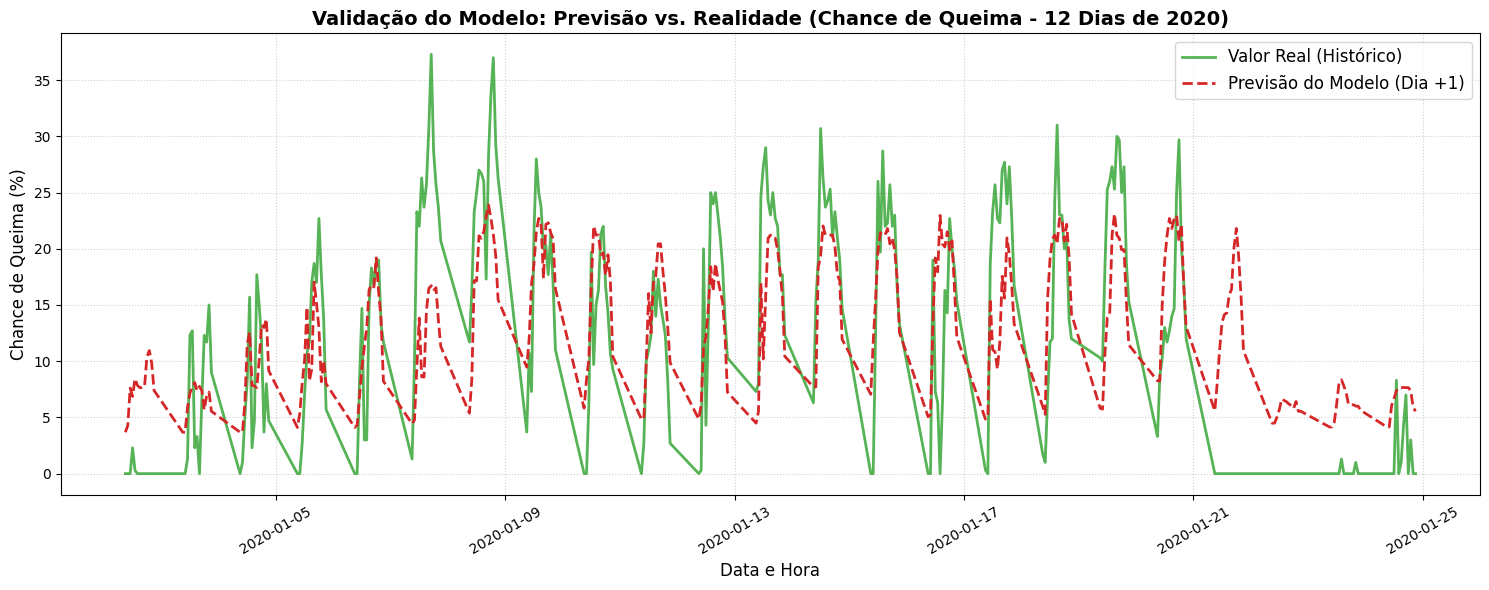

In [ ]:
# 1. Prepara os dados de teste para o Dia 1 de Queima
target_name = 'TARGET_QUEIMA_DIA_1'
df_temp = filtered_file.dropna(subset=[target_name] + features)

X_test = df_temp[df_temp['TEMPO-HORA'] > fim_treino][features]
y_test = df_temp[df_temp['TEMPO-HORA'] > fim_treino][target_name]
datas_test = df_temp[df_temp['TEMPO-HORA'] > fim_treino]['TEMPO-HORA']

# 2. Faz a previsão
y_pred = np.clip(modelos_queima[1].predict(X_test), 0, 100)

# 3. Seleciona um intervalo (Zoom de 300 horas / ~12 dias) para o gráfico ficar legível
zoom_limite = 300
datas_zoom = datas_test.iloc[:zoom_limite]
reais_zoom = y_test.iloc[:zoom_limite]
predicoes_zoom = y_pred[:zoom_limite]

# 4. Plota o Gráfico
plt.figure(figsize=(15, 6))
plt.plot(datas_zoom, reais_zoom, label='Valor Real (Histórico)', color='#2ca02c', linewidth=2, alpha=0.8)
plt.plot(datas_zoom, predicoes_zoom, label='Previsão do Modelo (Dia +1)', color='#d62728', linestyle='--', linewidth=2)

plt.title('Validação do Modelo: Previsão vs. Realidade (Chance de Queima - 12 Dias de 2020)', fontsize=14, fontweight='bold')
plt.xlabel('Data e Hora', fontsize=12)
plt.ylabel('Chance de Queima (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [393]:
joblib.dump(modelos_chuva, 'modelos_chuva_7d.pkl')
joblib.dump(modelos_seca, 'modelos_seca_7d.pkl')
joblib.dump(modelos_queima, 'modelos_queima_7d.pkl')

print("Arquivos .pkl gerados com sucesso!")

Arquivos .pkl gerados com sucesso!
